In [7]:
#!pip install pandas numpy opencv-python matplotlib

(np.float64(-0.5), np.float64(499.5), np.float64(499.5), np.float64(-0.5))

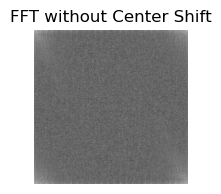

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2

original = cv2.imread(r"C:\Users\soura\Documents\Sem 6 Labs\IPMV\Images\test_image.tif")
original = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
f = np.fft.fft2(original)
plt.figure(figsize=(2,2))
plt.imshow(20*np.log(np.abs(f)+1), cmap='gray')
plt.title("FFT without Center Shift")
plt.axis('off')

(np.float64(-0.5), np.float64(499.5), np.float64(499.5), np.float64(-0.5))

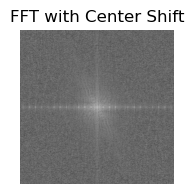

In [9]:
fshift = np.fft.fftshift(f)
magnitude = 20*np.log(np.abs(fshift)+1)
plt.figure(figsize=(2,2))
plt.imshow(magnitude, cmap='gray')
plt.title("FFT with Center Shift")
plt.axis('off')

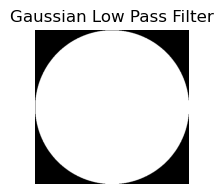

In [26]:
rows, cols = original.shape
crow, ccol = rows//2, cols//2

D0 = 250

H1 = np.zeros((rows, cols), dtype=np.float32)

for u in range(rows):
    for v in range(cols):

        D = np.sqrt((u-crow)**2 + (v-ccol)**2)

        H1[u,v] = np.exp(-(D**2)/(2*(D0**2)))

plt.figure(figsize=(2,2))
plt.imshow(H1, cmap='gray')
plt.title("Gaussian Low Pass Filter")
plt.axis('off')
plt.show()

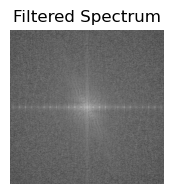

In [20]:
Gshift = fshift * H1
filtered_spec = 20 * np.log(np.abs(Gshift)+1)
plt.figure(figsize=(2,2))
plt.imshow(filtered_spec, cmap='gray')
plt.title("Filtered Spectrum")
plt.axis('off')
plt.show()

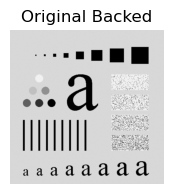

In [25]:
f_ishift = np.fft.ifftshift(Gshift)
img_back = np.fft.ifft2(f_ishift)
img_back= np.abs(img_back)
plt.figure(figsize=(2,2))
plt.imshow(img_back, cmap='gray')
plt.title("Original Backed")
plt.axis('off')
plt.show()